[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-2/trim-filter-messages.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239435-lesson-4-trim-and-filter-messages)

# Filtering and trimming messages

## Review

Now, we have a deeper understanding of a few things: 

* How to customize the graph state schema
* How to define custom state reducers
* How to use multiple graph state schemas

## Goals

Now, we can start using these concepts with models in LangGraph!
 
In the next few sessions, we'll build towards a chatbot that has long-term memory.

Because our chatbot will use messages, let's first talk a bit more about advanced ways to work with messages in graph state.

In [1]:
%%capture --no-stderr
%pip install --quiet -U langchain_core langgraph langchain_groq transformers

In [2]:
import os, httpx
from dotenv import load_dotenv

# Load .env using absolute path (override=True to ensure it always loads fresh)
load_dotenv("/Users/L107127/Library/CloudStorage/OneDrive-EliLillyandCompany/Desktop/langchain-academy/.env", override=True)

CA_BUNDLE = "/Users/L107127/Library/CloudStorage/OneDrive-EliLillyandCompany/Desktop/langchain-academy/ca-bundle.pem"
os.environ["SSL_CERT_FILE"] = CA_BUNDLE
os.environ["REQUESTS_CA_BUNDLE"] = CA_BUNDLE

# Create a custom httpx client with the CA bundle
http_client = httpx.Client(verify=CA_BUNDLE)
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [2]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("GROQ_API_KEY")

We'll use [LangSmith](https://docs.smith.langchain.com/) for [tracing](https://docs.smith.langchain.com/concepts/tracing).

We'll log to a project, `langchain-academy`. 

In [4]:

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "langchain-academy"

## Messages as state

First, let's define some messages.

In [5]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
messages = [AIMessage(f"So you said you were researching ocean mammals?", name="Bot")]
messages.append(HumanMessage(f"Yes, I know about whales. But what others should I learn about?", name="Lance"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?


Recall we can pass them to a chat model.

In [7]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="qwen/qwen3-32b")
llm.invoke(messages).content

'<think>\nOkay, the user mentioned they\'re researching ocean mammals and already know about whales. They want to know others to learn about. I need to list some other ocean mammals but also make sure they\'re categorized correctly. Let me start by recalling different types of ocean mammals. \n\nFirst, cetaceans besides whales. There are dolphins and porpoises. Wait, are porpoises really a separate category? Yes, they\'re in the family Phocoenidae, while dolphins are Delphinidae. So I should mention both. Then there\'s the orca, which is technically a dolphin, right? That\'s a detail to note.\n\nNext, pinnipeds. Seals, sea lions, and walruses. Each has different characteristics. For example, seals don\'t have ear flaps, while sea lions do. Walruses have those big tusks. Should I mention their habitats? Maybe, like some seals live in the Arctic or Antarctic.\n\nThen there\'s the sirenians: manatees and dugongs. They’re herbivores and live in warm coastal areas. Important to note their c

We can run our chat model in a simple graph with `MessagesState`.

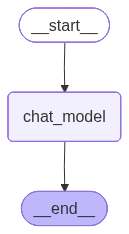

In [8]:
from IPython.display import Image, display
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END

# Node
def chat_model_node(state: MessagesState):
    return {"messages": llm.invoke(state["messages"])}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

<think>
Okay, the user mentioned they're researching ocean mammals and know about whales. They want to know about others. Let me start by thinking about the different categories of ocean mammals. There are cetaceans (whales, dolphins, porpoises), pinnipeds (seals, sea lions, walruses), sirenians (manatees, dugongs), and maybe others like otters or polar bears, but those are semi-aquatic.

First, I should list the main groups. For cetaceans, besides the well-known whales, there are different types like baleen whales and toothed whales. The user might already know some, but maybe they can delve deeper into specific

## Reducer

A practical challenge when working with messages is managing long-running conversations. 

Long-running conversations result in high token usage and latency if we are not careful, because we pass a growing list of messages to the model.

We have a few ways to address this.

First, recall the trick we saw using `RemoveMessage` and the `add_messages` reducer.

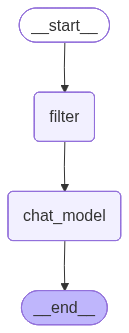

In [10]:
from langchain_core.messages import RemoveMessage

# Nodes
def filter_messages(state: MessagesState):
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"messages": delete_messages}

def chat_model_node(state: MessagesState):    
    return {"messages": [llm.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("filter", filter_messages)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "filter")
builder.add_edge("filter", "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
# Message list with a preamble
messages = [AIMessage("Hi.", name="Bot", id="1")]
messages.append(HumanMessage("Hi.", name="Lance", id="2"))
messages.append(AIMessage("So you said you were researching ocean mammals?", name="Bot", id="3"))
messages.append(HumanMessage("Yes, I know about whales. But what others should I learn about?", name="Lance", id="4"))

# Invoke
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

<think>
Okay, the user is interested in ocean mammals beyond just whales. I need to provide a comprehensive list of other marine mammals they should consider. Let me start by recalling the main categories of ocean mammals. There are four primary groups: cetaceans (whales, dolphins, porpoises), pinnipeds (seals, sea lions, walruses), sirenians (manatees, dugongs), and polar bears (though polar bears are sometimes debated as they're not fully aquatic but still rely on the ocean). 

First, cetaceans are already mentioned, so maybe I should focus on the others. Pinnipeds are a good category to expand on. I should lis

## Filtering messages

If you don't need or want to modify the graph state, you can just filter the messages you pass to the chat model.

For example, just pass in a filtered list: `llm.invoke(messages[-1:])` to the model.

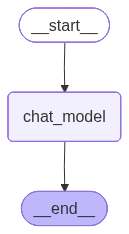

In [12]:
# Node
def chat_model_node(state: MessagesState):
    return {"messages": [llm.invoke(state["messages"][-1:])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

Let's take our existing list of messages, append the above LLM response, and append a follow-up question.

In [13]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me more about Narwhals!", name="Lance"))

In [14]:
for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Lance

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

<think>
Okay, the user is interested in ocean mammals beyond just whales. I need to provide a comprehensive list of other marine mammals they should consider. Let me start by recalling the main categories of ocean mammals. There are four primary groups: cetaceans (whales, dolphins, porpoises), pinnipeds (seals, sea lions, walruses), sirenians (manatees, dugongs), and polar bears (though polar bears are sometimes debated as

In [15]:
# Invoke, using message filtering
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Lance

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

<think>
Okay, the user is interested in ocean mammals beyond just whales. I need to provide a comprehensive list of other marine mammals they should consider. Let me start by recalling the main categories of ocean mammals. There are four primary groups: cetaceans (whales, dolphins, porpoises), pinnipeds (seals, sea lions, walruses), sirenians (manatees, dugongs), and polar bears (though polar bears are sometimes debated as

The state has all of the mesages.

But, let's look at the LangSmith trace to see that the model invocation only uses the last message:

https://smith.langchain.com/public/75aca3ce-ef19-4b92-94be-0178c7a660d9/r

## Trim messages

Another approach is to [trim messages](https://python.langchain.com/v0.2/docs/how_to/trim_messages/#getting-the-last-max_tokens-tokens), based upon a set number of tokens. 

This restricts the message history to a specified number of tokens.

While filtering only returns a post-hoc subset of the messages between agents, trimming restricts the number of tokens that a chat model can use to respond.

See the `trim_messages` below.

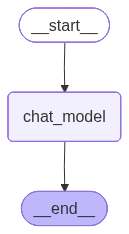

In [24]:
from langchain_core.messages import trim_messages

# Node
def chat_model_node(state: MessagesState):
    messages = trim_messages(
            state["messages"],
            max_tokens=50,
            strategy="last",
            token_counter=llm,
            allow_partial=False,
        )
    return {"messages": [llm.invoke(messages)]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me where Orcas live!", name="Lance"))

In [26]:
# Invoke, using message trimming in the chat_model_node 
messages_out_trim = graph.invoke({'messages': messages})

In [27]:
for m in messages_out_trim['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Lance

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

<think>
Okay, the user is interested in ocean mammals beyond just whales. I need to provide a comprehensive list of other marine mammals they should consider. Let me start by recalling the main categories of ocean mammals. There are four primary groups: cetaceans (whales, dolphins, porpoises), pinnipeds (seals, sea lions, walruses), sirenians (manatees, dugongs), and polar bears (though polar bears are sometimes debated as

Let's look at the LangSmith trace to see the model invocation:

https://smith.langchain.com/public/b153f7e9-f1a5-4d60-8074-f0d7ab5b42ef/r